# Apprentissage Non Supervisé - Criminalité aux USA

**Dataset : crimes.csv**

Statistiques de criminalité dans 50 états américains. Sept types de crimes/délits repérés par leurs nombres annuels pour 100 000 habitants.

---

## Configuration et Imports

In [47]:
from utils_ans import *
setup_environment()

---
# I. Réduction de dimensions et Visualisation des données
---

## 1. Importation du jeu de données

In [ ]:
data = load_data('./data/crimes.csv')

Dimensions : (50, 8)
Colonnes : ['Etat ', 'Meutre', 'Rapt', 'Vol', 'Attaque', 'Viol', 'Larcin', 'Auto_Theft']

Aperçu :
        Etat   Meutre  Rapt    Vol  Attaque    Viol  Larcin  Auto_Theft
0     Alabama    14.2  25.2   96.8    278.3  1135.5  1881.9       280.7
1      Alaska    10.8  51.6   96.8    284.0  1331.7  3369.8       753.3
2     Arizona     9.5  34.2  138.2    312.3  2346.1  4467.4       439.5
3    Arkansas     8.8  27.6   83.2    203.4   972.6  1862.1       183.4
4  California    11.5  49.4  287.0    358.0  2139.4  3499.8       663.5


In [49]:
data.describe()

,Meutre,Rapt,Vol,Attaque,Viol,Larcin,Auto_Theft
count,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,7.444000,25.73400,124.092000,211.300000,1291.904000,2671.288000,377.526000
std,3.866769,10.75963,88.348567,100.253049,432.455711,725.908707,193.394418
min,0.900000,9.00000,13.300000,43.800000,446.100000,1239.900000,144.400000
25%,4.225000,18.32500,64.950000,148.850000,1000.075000,2248.900000,245.775000
50%,7.300000,24.10000,106.050000,197.600000,1265.050000,2617.450000,333.850000
75%,10.100000,32.52500,155.850000,282.575000,1529.825000,3007.600000,460.125000
max,15.800000,51.60000,472.600000,485.300000,2453.100000,4467.400000,1140.100000


In [50]:
X, labels, feature_names = prepare_data(data, feature_cols=slice(1, None), label_col=0)

Matrice X : (50, 7)
Labels : (50,)
Features : ['Meutre', 'Rapt', 'Vol', 'Attaque', 'Viol', 'Larcin', 'Auto_Theft']


## 2. Analyse en Composantes Principales (ACP)

In [51]:
X_scaled, X_pca, pca, scaler = perform_pca(X)

In [52]:
cumulative = print_variance_explained(pca)

Variance expliquée par chaque composante :
  PC1: 58.79%
  PC2: 17.70%
  PC3: 10.37%
  PC4: 4.52%
  PC5: 3.69%
  PC6: 3.17%
  PC7: 1.77%

Variance cumulée :
  PC1-PC1: 58.79%
  PC1-PC2: 76.48%
  PC1-PC3: 86.85%
  PC1-PC4: 91.37%
  PC1-PC5: 95.06%
  PC1-PC6: 98.23%
  PC1-PC7: 100.00%


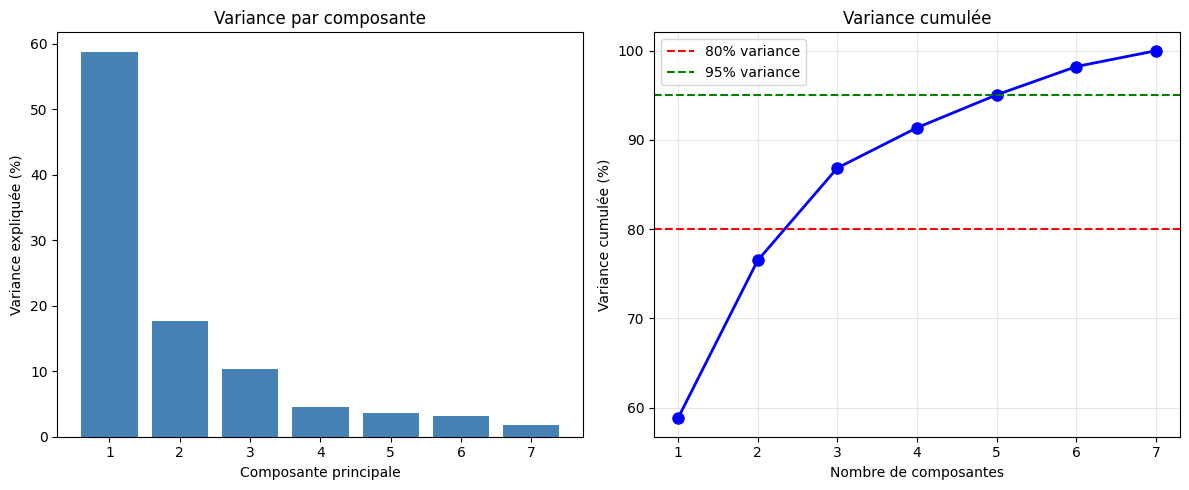

array([0.58785136, 0.76481162, 0.86849971, 0.91370429, 0.95055778,
       0.98227771, 1.        ])

In [53]:
plot_variance(pca)

### Réponse : Nombre d'axes à retenir

- PC1 : ~59% de variance
- PC1+PC2 : ~76% de variance
- PC1+PC2+PC3 : ~87% de variance

**Conclusion : 2 à 3 axes** sont recommandés pour une bonne représentation.

In [54]:
loadings_df = get_loadings(pca, feature_names)

Corrélations des variables avec les axes principaux :
              PC1    PC2    PC3
Meutre      0.615  0.707  0.153
Rapt        0.885  0.190 -0.210
Vol         0.813 -0.047  0.427
Attaque     0.813  0.386 -0.060
Viol        0.902 -0.229 -0.181
Larcin      0.732 -0.452 -0.464
Auto_Theft  0.605 -0.565  0.489


### Interprétation des axes

**PC1 - "Niveau global de criminalité"** : toutes les variables corrélées positivement

**PC2 - "Type de criminalité"** : opposition crimes violents vs crimes contre les biens

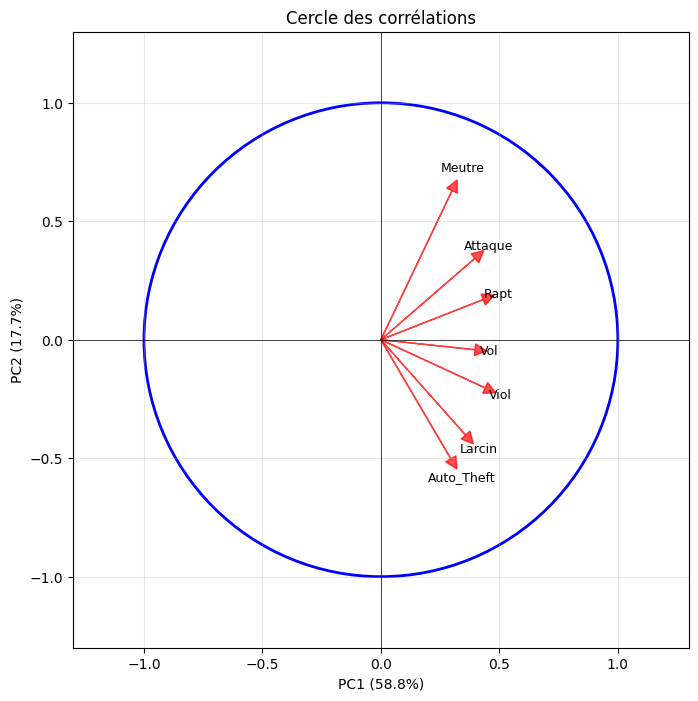

In [55]:
plot_correlation_circle(pca, feature_names)

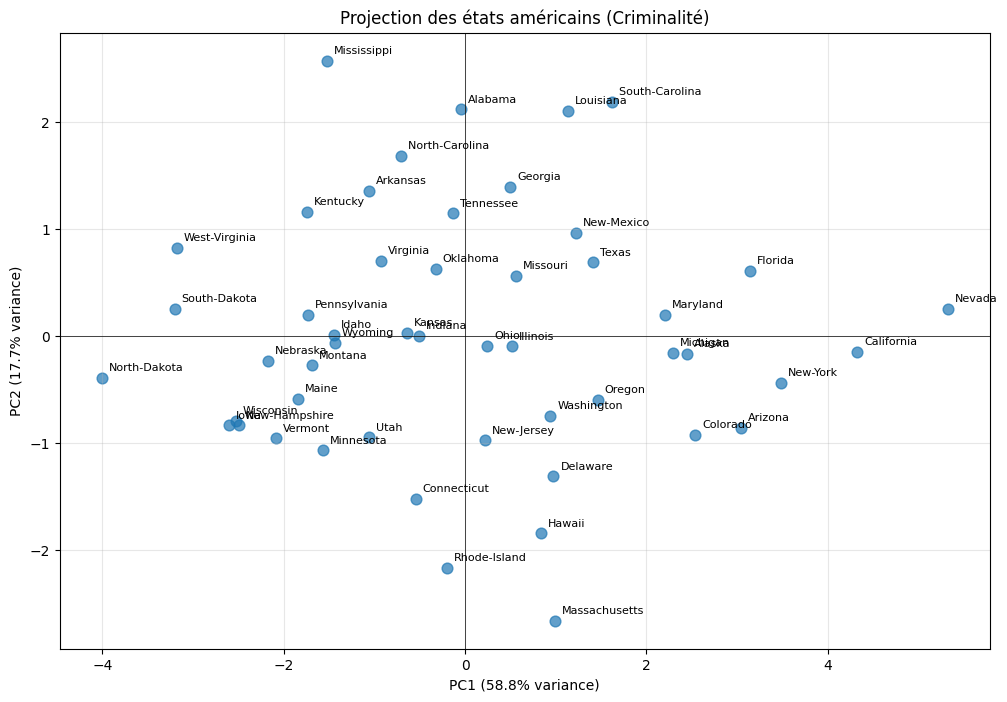

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=60, alpha=0.7)

for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(str(label), xy=(x, y), xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Projection des états américains (Criminalité)')
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.show()

---
# II. Clustering
---

## 1. KMeans (3 clusters)

In [ ]:
clustering_kmeans, kmeans = apply_kmeans(X_scaled, n_clusters=3)

print("Clusters (3) :")
print("=" * 60)
for i in range(3):
    members = labels[clustering_kmeans == i]
    print(f"\nCluster {i} ({len(members)} éléments) :")
    print(f"  {list(members)}")

Clusters (3) :

Cluster 0 (17 éléments) :
  ['Connecticut', 'Idaho', 'Iowa', 'Maine', 'Minnesota', 'Montana', 'Nebraska', 'New-Hampshire', 'North-Dakota', 'Pennsylvania', 'Rhode-Island', 'South-Dakota', 'Utah', 'Vermont', 'West-Virginia', 'Wisconsin', 'Wyoming']

Cluster 1 (19 éléments) :
  ['Alabama', 'Arkansas', 'Georgia', 'Illinois', 'Indiana', 'Kansas', 'Kentucky', 'Louisiana', 'Mississippi', 'Missouri', 'New-Jersey', 'New-Mexico', 'North-Carolina ', 'Ohio', 'Oklahoma', 'South-Carolina ', 'Tennessee', 'Texas', 'Virginia']

Cluster 2 (14 éléments) :
  ['Alaska', 'Arizona', 'California', 'Colorado', 'Delaware', 'Florida', 'Hawaii', 'Maryland', 'Massachusetts', 'Michigan', 'Nevada', 'New-York', 'Oregon', 'Washington']


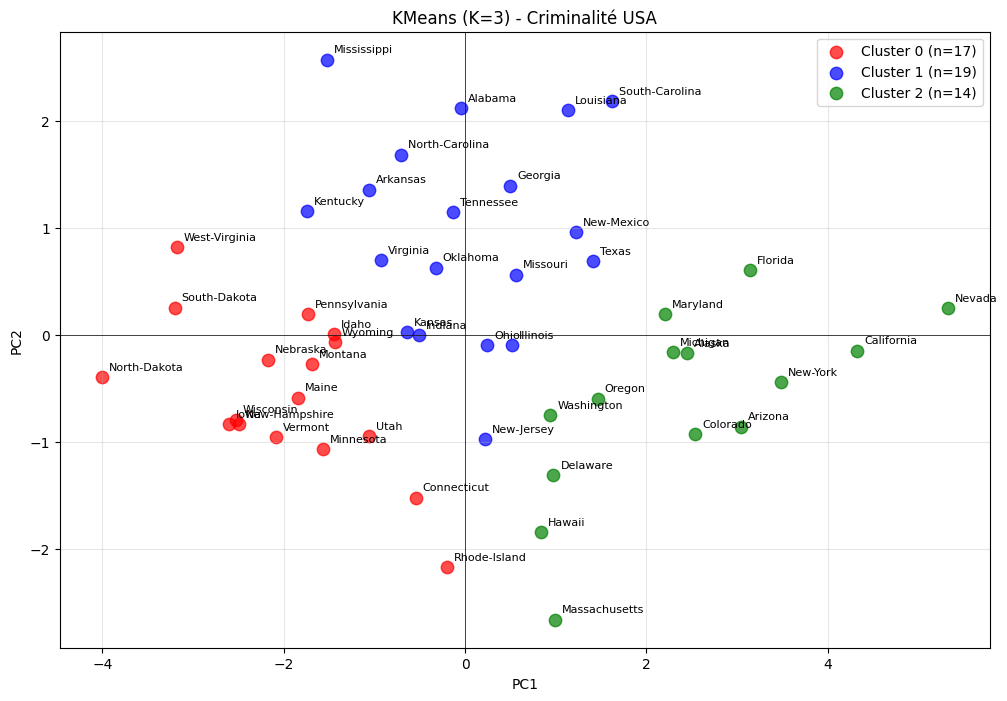

In [58]:
plot_clustering(X_pca, clustering_kmeans, labels, 'KMeans (K=3) - Criminalité USA')

## 2. AgglomerativeClustering

Clusters (3) :

Cluster 0 (48 éléments) :
  ['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New-Hampshire', 'New-Jersey', 'New-Mexico', 'North-Carolina ', 'North-Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode-Island', 'South-Carolina ', 'South-Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West-Virginia', 'Wisconsin', 'Wyoming']

Cluster 1 (1 éléments) :
  ['New-York']

Cluster 2 (1 éléments) :
  ['Alaska']


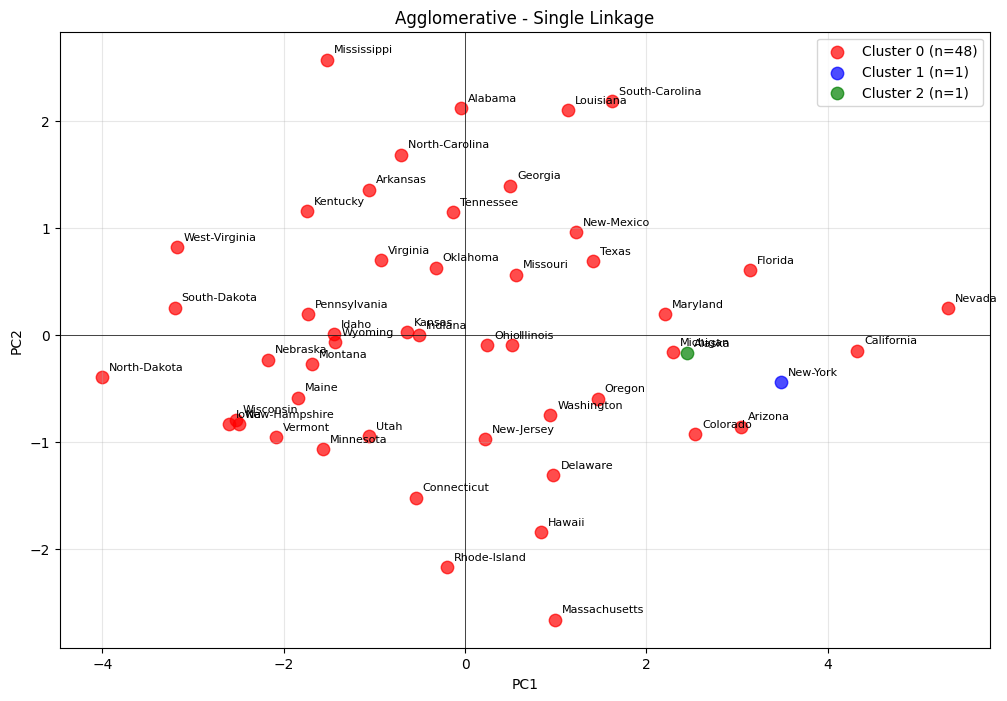

In [ ]:
clustering_single = apply_agglomerative(X_scaled, n_clusters=3, linkage='single')

print("Clusters Single (3) :")
for i in range(3):
    members = labels[clustering_single == i]
    print(f"Cluster {i} ({len(members)} éléments): {list(members)}")

plot_clustering(X_pca, clustering_single, labels, 'Agglomerative - Single Linkage')

Clusters (3) :

Cluster 0 (23 éléments) :
  ['Alaska', 'Arizona', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Hawaii', 'Illinois', 'Maryland', 'Massachusetts', 'Michigan', 'Missouri', 'Nevada', 'New-Jersey', 'New-Mexico', 'New-York', 'Ohio', 'Oregon', 'Rhode-Island', 'South-Carolina ', 'Texas', 'Washington']

Cluster 1 (17 éléments) :
  ['Idaho', 'Indiana', 'Iowa', 'Kansas', 'Maine', 'Minnesota', 'Montana', 'Nebraska', 'New-Hampshire', 'North-Dakota', 'South-Dakota', 'Utah', 'Vermont', 'Virginia', 'West-Virginia', 'Wisconsin', 'Wyoming']

Cluster 2 (10 éléments) :
  ['Alabama', 'Arkansas', 'Georgia', 'Kentucky', 'Louisiana', 'Mississippi', 'North-Carolina ', 'Oklahoma', 'Pennsylvania', 'Tennessee']


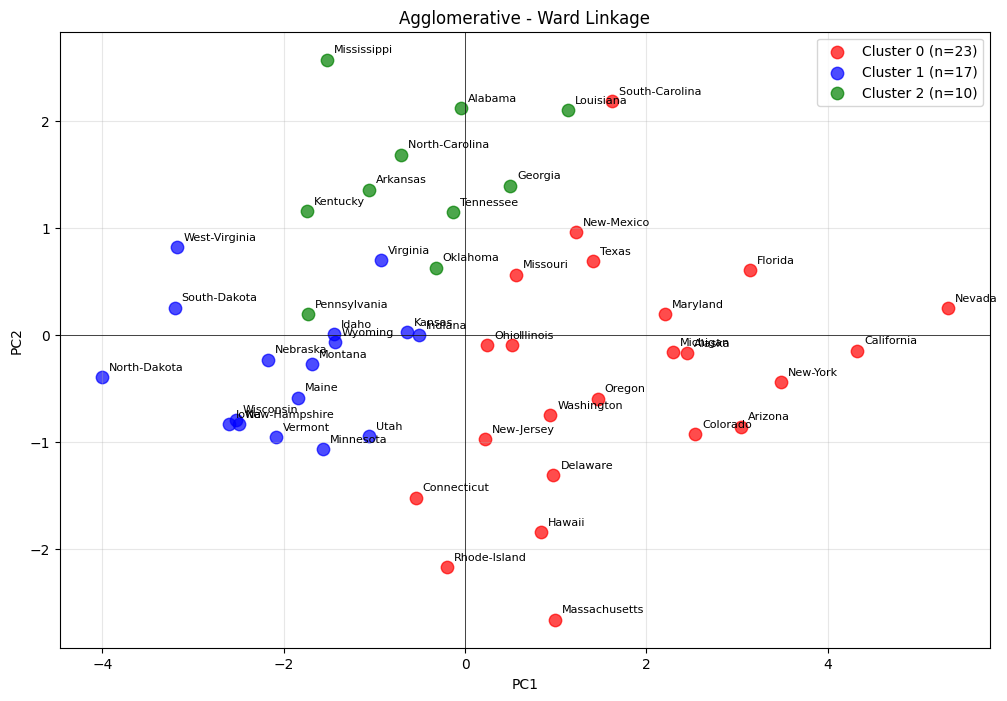

In [ ]:
clustering_ward = apply_agglomerative(X_scaled, n_clusters=3, linkage='ward')

print("Clusters Ward (3) :")
for i in range(3):
    members = labels[clustering_ward == i]
    print(f"Cluster {i} ({len(members)} éléments): {list(members)}")

plot_clustering(X_pca, clustering_ward, labels, 'Agglomerative - Ward Linkage')

Clusters (3) :

Cluster 0 (12 éléments) :
  ['Alaska', 'Arizona', 'California', 'Colorado', 'Florida', 'Maryland', 'Michigan', 'Nevada', 'New-Mexico', 'New-York', 'Oregon', 'Washington']

Cluster 1 (36 éléments) :
  ['Alabama', 'Arkansas', 'Connecticut', 'Delaware', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'New-Hampshire', 'New-Jersey', 'North-Carolina ', 'North-Dakota', 'Ohio', 'Oklahoma', 'Pennsylvania', 'South-Carolina ', 'South-Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'West-Virginia', 'Wisconsin', 'Wyoming']

Cluster 2 (2 éléments) :
  ['Massachusetts', 'Rhode-Island']


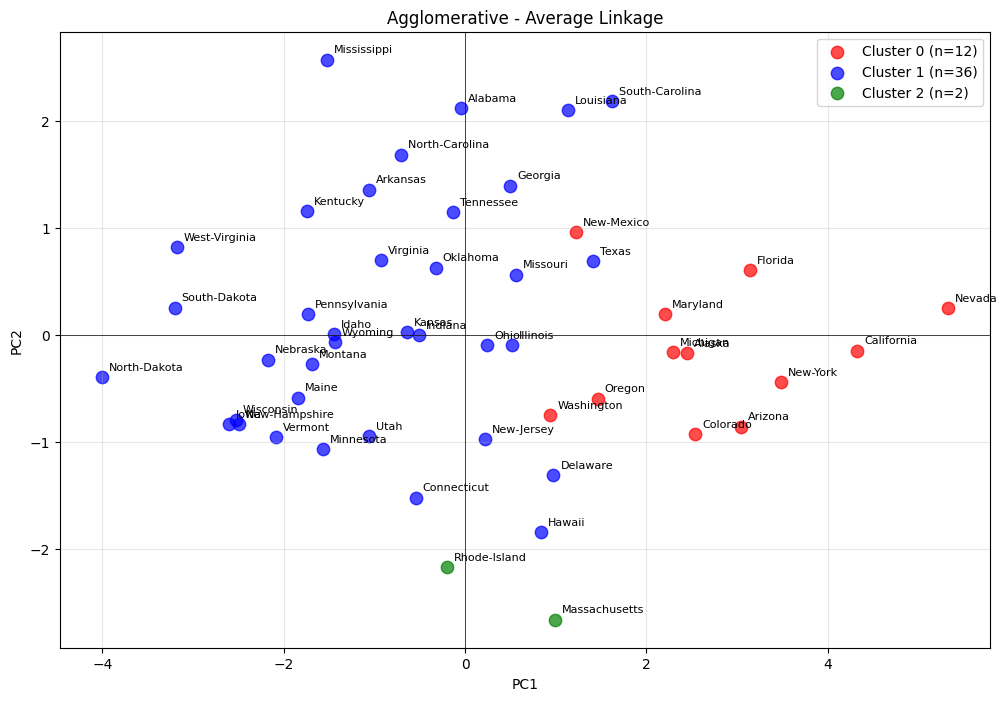

In [ ]:
clustering_average = apply_agglomerative(X_scaled, n_clusters=3, linkage='average')

print("Clusters Average (3) :")
for i in range(3):
    members = labels[clustering_average == i]
    print(f"Cluster {i} ({len(members)} éléments): {list(members)}")

plot_clustering(X_pca, clustering_average, labels, 'Agglomerative - Average Linkage')

## 3. Détermination du nombre optimal (Silhouette)

In [62]:
scores, best_k = compute_silhouette_scores(X_scaled)

Indices Silhouette pour KMeans :
K=2: Silhouette = 0.3206
K=3: Silhouette = 0.2568
K=4: Silhouette = 0.2836
K=5: Silhouette = 0.2792
K=6: Silhouette = 0.2642
K=7: Silhouette = 0.2261
K=8: Silhouette = 0.2231
K=9: Silhouette = 0.1911

Meilleure partition : K=2 (Silhouette = 0.3206)


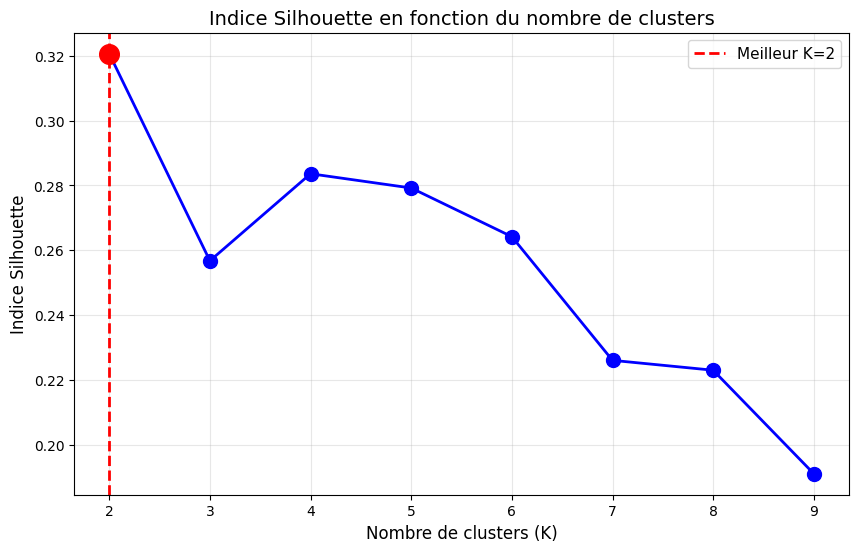

In [63]:
plot_silhouette_scores(scores)

## 4. Comparaison des méthodes

In [64]:
results = compare_methods(X_scaled, n_clusters=3)

Comparaison des méthodes pour 3 clusters :
KMeans          : Silhouette = 0.2568
Single          : Silhouette = 0.1769
Ward            : Silhouette = 0.2134
Average         : Silhouette = 0.3154
Hybride         : Silhouette = 0.2505

Meilleure méthode : Average (Silhouette = 0.3154)


## 5. Avantages et inconvénients

### Classification Hiérarchique (AgglomerativeClustering)

**Avantages :**
- Pas besoin de spécifier K à l'avance
- Produit une hiérarchie complète (dendrogramme)
- Résultats déterministes
- Peut découvrir des clusters de formes arbitraires (avec single linkage)

**Inconvénients :**
- Complexité O(n²) ou O(n³)
- Ne passe pas à l'échelle pour grands datasets
- Décisions de fusion irréversibles
- Single linkage : effet de chaînage

---

### Partitionnement (KMeans)

**Avantages :**
- Très rapide O(n×K×iterations)
- Scalable pour grands datasets
- Clusters compacts et bien séparés
- Simple à comprendre et implémenter

**Inconvénients :**
- Nécessite K à l'avance
- Sensible à l'initialisation (non-déterministe)
- Sensible aux outliers
- Assume des clusters sphériques

## 6. Approche Hybride

In [ ]:
clustering_hyb, centers = clustering_hybride(X_scaled, n_clusters=3)
score_hyb = metrics.silhouette_score(X_scaled, clustering_hyb, metric='euclidean')
print(f"Approche Hybride - Silhouette : {score_hyb:.4f}")

print("\nClusters Hybride (3) :")
for i in range(3):
    members = labels[clustering_hyb == i]
    print(f"Cluster {i} ({len(members)} éléments): {list(members)}")

Approche Hybride - Silhouette : 0.2505
Clusters (3) :

Cluster 0 (17 éléments) :
  ['Alaska', 'Arizona', 'California', 'Colorado', 'Delaware', 'Florida', 'Hawaii', 'Maryland', 'Massachusetts', 'Michigan', 'Nevada', 'New-Jersey', 'New-Mexico', 'New-York', 'Oregon', 'Texas', 'Washington']

Cluster 1 (18 éléments) :
  ['Connecticut', 'Idaho', 'Iowa', 'Kansas', 'Maine', 'Minnesota', 'Montana', 'Nebraska', 'New-Hampshire', 'North-Dakota', 'Pennsylvania', 'Rhode-Island', 'South-Dakota', 'Utah', 'Vermont', 'West-Virginia', 'Wisconsin', 'Wyoming']

Cluster 2 (15 éléments) :
  ['Alabama', 'Arkansas', 'Georgia', 'Illinois', 'Indiana', 'Kentucky', 'Louisiana', 'Mississippi', 'Missouri', 'North-Carolina ', 'Ohio', 'Oklahoma', 'South-Carolina ', 'Tennessee', 'Virginia']


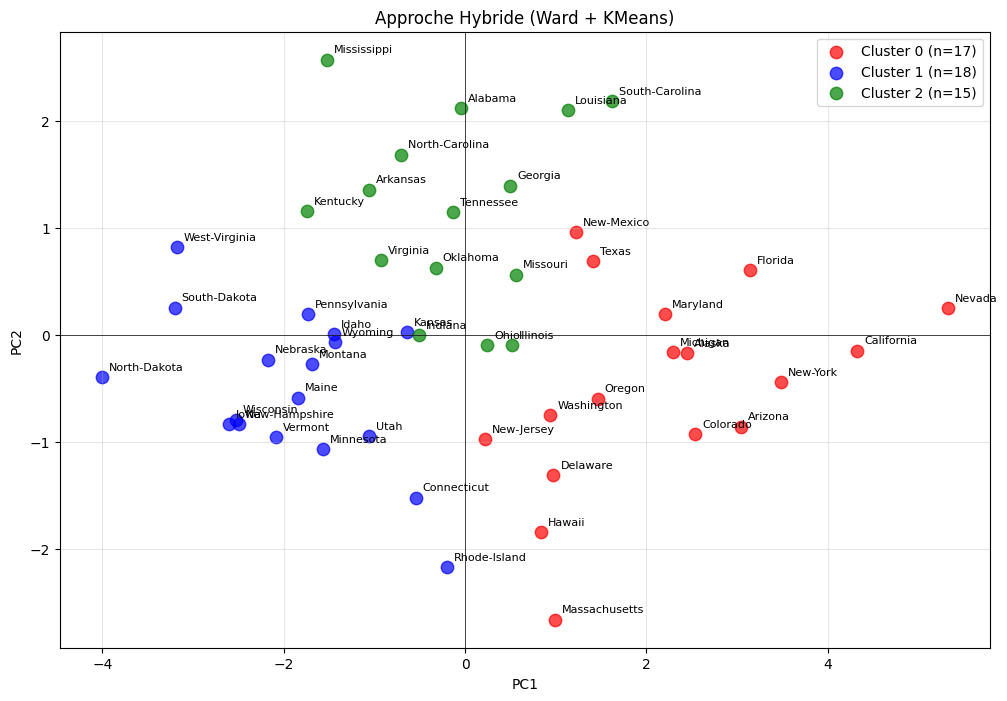

In [67]:
plot_clustering(X_pca, clustering_hyb, labels, 'Approche Hybride (Ward + KMeans)')

---
# Conclusion

1. **ACP** : 2-3 composantes pour ~80% de variance
2. **Interprétation** : PC1 = niveau global, PC2 = type de criminalité
3. **Clustering** : Ward ou Average donnent les meilleurs résultats
4. **Segmentation** : États classifiables selon leur profil criminel